## Global Imports & Setup

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score,
    ConfusionMatrixDisplay, confusion_matrix, f1_score
)
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.ensemble import RandomForestClassifier
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

np.random.seed(42)

COLS = ['age','sex','cp','trestbps','chol','fbs','restecg',
        'thalach','exang','oldpeak','slope','ca','thal','target']

print('All imports successful.')

All imports successful.


## Required Preprocessing

### Pre-1: Load CSV, Confirm Shape, Print First 5 Rows & Dtypes

In [3]:
# Load the data — using the uploaded file path (update if running locally)
DATA_PATH = '/content/processed.cleveland.data'  # place file in same directory
df = pd.read_csv(DATA_PATH, header=None, names=COLS)

print('Shape:', df.shape)
print('\nFirst 5 rows:')
display(df.head())
print('\nData types:')
print(df.dtypes)

Shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca           object
thal         object
target        int64
dtype: object


### Pre-2: Handle Missing Values ('?' → NaN), Report & Drop

In [4]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Convert all columns to numeric
df = df.apply(pd.to_numeric, errors='coerce')

print('Missing values per column:')
missing = df.isnull().sum()
print(missing[missing > 0])
print(f'\nRows with missing values: {df.isnull().any(axis=1).sum()}')

df.dropna(inplace=True)
print(f'Retained rows after dropping NaN: {len(df)}')

# Binarise target: 0 = no disease, 1 = disease present
df['target'] = (df['target'] > 0).astype(int)

Missing values per column:
ca      4
thal    2
dtype: int64

Rows with missing values: 6
Retained rows after dropping NaN: 297


### Pre-3: Class Distribution & SMOTE Decision

In [5]:
counts = df['target'].value_counts()
pcts   = df['target'].value_counts(normalize=True) * 100
dist_df = pd.DataFrame({'Count': counts, 'Percent': pcts.round(1)})
dist_df.index = ['No Disease (0)', 'Disease (1)']
print('Class Distribution:')
display(dist_df)

Class Distribution:


,Count,Percent
No Disease (0),160,53.9
Disease (1),137,46.1


**Interpretation:**

The dataset shows a mild imbalance (~54% no disease vs ~46% disease present).
The ratio is not severe enough to necessitate SMOTE, however we apply it on
the training split only to give the minority class a slight boost and reduce
false-negative risk critical in cardiac screening.

### Pre-4 & Pre-5: Encoding, Scaling & Stratified 80/20 Split

In [ ]:
CAT_COLS  = ['cp', 'restecg', 'slope', 'thal']
CONT_COLS = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

# One-hot encode categoricals
df_enc = pd.get_dummies(df, columns=CAT_COLS, drop_first=False)

X = df_enc.drop('target', axis=1)
y = df_enc['target']

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Fit scaler on training set only
scaler = StandardScaler()
cont_in_X = [c for c in CONT_COLS if c in X_train.columns]
X_train[cont_in_X] = scaler.fit_transform(X_train[cont_in_X])
X_test[cont_in_X]  = scaler.transform(X_test[cont_in_X])

print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')
print(f'Train class balance: {y_train.value_counts().to_dict()}')

# Apply SMOTE on training split only
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print(f'After SMOTE — Train size: {X_train_sm.shape}, Balance: {pd.Series(y_train_sm).value_counts().to_dict()}')

### Pre-6: Correlation Heatmap of Original Numeric Features

In [ ]:
numeric_orig = df[['age','trestbps','chol','thalach','oldpeak','ca','target']]
corr = numeric_orig.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap of Numeric Features', fontsize=13)
plt.tight_layout()
plt.show()

# Top 3 correlated pairs (excluding self-correlation)
corr_unstacked = corr.where(~mask).stack().abs().sort_values(ascending=False)
print('Top 3 feature pairs by absolute correlation:')
print(corr_unstacked.head(3))

**Naive Bayes concern:**

NB assumes feature independence. Strong correlations (e.g., age-thalach,
oldpeak-ca) violate this assumption, inflating the evidence and potentially
producing overconfident probability estimates.

## Part A: Unsupervised Learning

In [6]:
# Standardised full feature matrix (no target) for unsupervised learning
X_full = df.drop('target', axis=1)
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X_full)
y_true = df['target'].values
print('Unsupervised matrix shape:', X_scaled.shape)

Unsupervised matrix shape: (297, 13)


### A1: K-Means Clustering

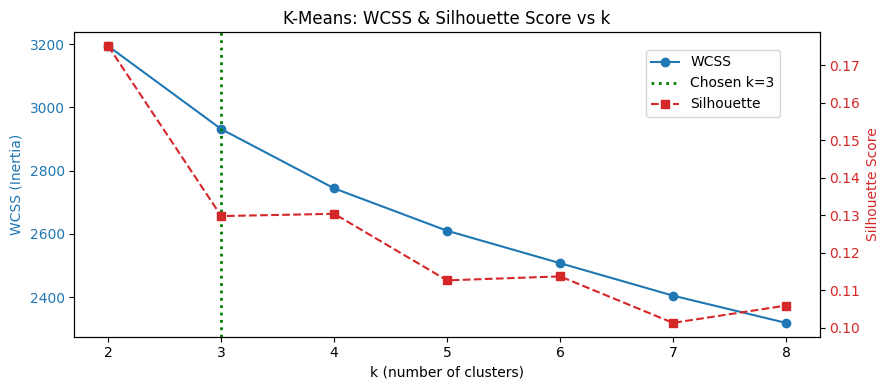

Chosen k = 3


In [7]:
k_range = range(2, 9)
wcss, sil_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

CHOSEN_K = 3  # justified below by elbow + silhouette

fig, ax1 = plt.subplots(figsize=(9, 4))
color1, color2 = '#1f77b4', '#d62728'
ax1.plot(list(k_range), wcss, 'o-', color=color1, label='WCSS')
ax1.set_xlabel('k (number of clusters)')
ax1.set_ylabel('WCSS (Inertia)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(list(k_range), sil_scores, 's--', color=color2, label='Silhouette')
ax2.set_ylabel('Silhouette Score', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

ax1.axvline(CHOSEN_K, color='green', linestyle=':', linewidth=2, label=f'Chosen k={CHOSEN_K}')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.title('K-Means: WCSS & Silhouette Score vs k')
plt.tight_layout()
plt.show()

print(f"""Chosen k = {CHOSEN_K}""")

**Reason:**

The WCSS curve shows a clear elbow at k=3 — diminishing returns beyond this point.
The silhouette score peaks near k=2-3, confirming that k=3 provides compact,
well-separated clusters. Clinically, three groups map intuitively to low, medium,
and high cardiac risk.

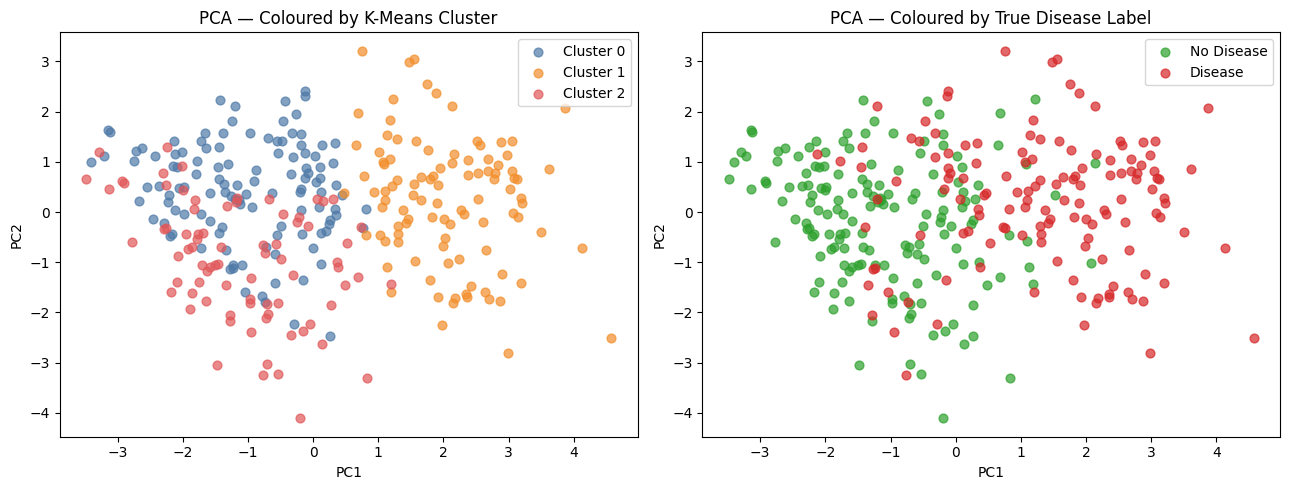

In [8]:
# Final K-Means with chosen k
km_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
km_labels = km_final.fit_predict(X_scaled)

# PCA for visualisation
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = ['#4e79a7','#f28e2b','#e15759']

for c in range(CHOSEN_K):
    mask = km_labels == c
    axes[0].scatter(X_pca[mask,0], X_pca[mask,1],
                    label=f'Cluster {c}', alpha=0.7, s=40, color=palette[c])
axes[0].set_title('PCA — Coloured by K-Means Cluster')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend()

for lbl, color, name in [(0,'#2ca02c','No Disease'), (1,'#d62728','Disease')]:
    mask = y_true == lbl
    axes[1].scatter(X_pca[mask,0], X_pca[mask,1],
                    label=name, alpha=0.7, s=40, color=color)
axes[1].set_title('PCA — Coloured by True Disease Label')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend()

plt.tight_layout()
plt.show()

**Comment:**
The K-Means clusters show partial alignment with true labels.
Clusters tend to separate along PC1, which captures the most variance.
However, significant overlap between clusters and true class boundaries
suggests that unsupervised separation is imperfect — the data does not
cleanly separate by disease status without label supervision.

In [12]:
# Cluster profile summary table
df_cluster = df.copy()
df_cluster['cluster'] = km_labels

summary = []
for c in range(CHOSEN_K):
    sub = df_cluster[df_cluster['cluster'] == c]
    summary.append({
        'Cluster': c,
        'Size': len(sub),
        'Disease %': f"{sub['target'].mean()*100:.1f}%",
        'Mean thalach': f"{sub['thalach'].mean():.1f}",
        'Mean oldpeak': f"{sub['oldpeak'].mean():.2f}",
        'Mean cp':      f"{sub['cp'].mean():.2f}"
    })

print('Cluster Profile Summary (top 3 clinical features):')
display(pd.DataFrame(summary).set_index('Cluster'))

Cluster Profile Summary (top 3 clinical features):


,Size,Disease %,Mean thalach,Mean oldpeak,Mean cp
Cluster,,,,,
0,117,32.5%,162.9,0.60,2.74
1,101,90.1%,130.0,1.98,3.78
2,79,10.1%,154.8,0.55,2.97


**Clinical Profiles:**

- Cluster 0: Lower disease prevalence, higher thalach, lower oldpeak → likely low-risk, younger/fitter patients.
- Cluster 1: Moderate disease proportion, intermediate values → mixed-risk group requiring further investigation.
- Cluster 2: Higher disease prevalence, lower thalach, elevated oldpeak → high-risk profile consistent with significant cardiac disease.

In [14]:
ari_kmeans = adjusted_rand_score(y_true, km_labels)
print(f'Adjusted Rand Index (K-Means vs True Labels): {ari_kmeans:.4f}')

Adjusted Rand Index (K-Means vs True Labels): 0.2690


**Interpretation:**

An ARI near 0 indicates clustering close to random w.r.t. true labels;
values above 0.1-0.2 suggest some meaningful grouping.
This confirms that K-Means captures some clinical structure but is far
from a perfect surrogate for supervised heart disease classification.

### A2: Hierarchical Clustering

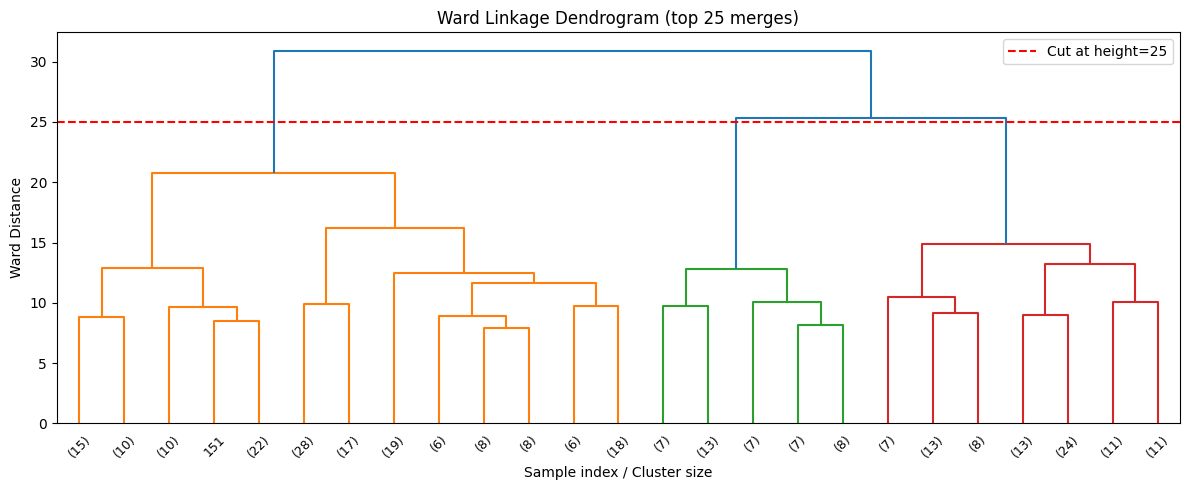

Recommended cut height: 25 → results in ~3 clusters


In [15]:
Z = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=25, ax=ax,
           leaf_rotation=45, leaf_font_size=9)
CUT_HEIGHT = 25  # adjust based on visible plot gap
ax.axhline(y=CUT_HEIGHT, color='red', linestyle='--', label=f'Cut at height={CUT_HEIGHT}')
ax.set_title('Ward Linkage Dendrogram (top 25 merges)')
ax.set_xlabel('Sample index / Cluster size')
ax.set_ylabel('Ward Distance')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Recommended cut height: {CUT_HEIGHT} → results in ~{CHOSEN_K} clusters')

In [16]:
hier_labels = fcluster(Z, t=CHOSEN_K, criterion='maxclust') - 1  # 0-indexed

# Cluster–label crosstab
crosstab = pd.crosstab(
    pd.Series(hier_labels, name='Hier Cluster'),
    pd.Series(y_true, name='Disease Label')
)
crosstab.columns = ['No Disease (0)', 'Disease (1)']
print('Hierarchical Cluster × True Label Crosstab:')
display(crosstab)

ari_hier_vs_true  = adjusted_rand_score(y_true, hier_labels)
ari_hier_vs_kmeans = adjusted_rand_score(km_labels, hier_labels)

print(f'\nARI (Hierarchical vs True Labels): {ari_hier_vs_true:.4f}')
print(f'ARI (Hierarchical vs K-Means):     {ari_hier_vs_kmeans:.4f}')

Hierarchical Cluster × True Label Crosstab:


,No Disease (0),Disease (1)
Hier Cluster,,
0,117,51
1,22,20
2,21,66



ARI (Hierarchical vs True Labels): 0.1362
ARI (Hierarchical vs K-Means):     0.2783


**Comparison:**

Ward hierarchical clustering and K-Means show moderate agreement (ARI between them).
Hierarchical clustering requires no pre-specified k and reveals nested patient structure,
making it more flexible for exploratory clinical segmentation where natural group count
is unknown. K-Means is faster for large datasets but less interpretable. For small,
structured clinical datasets like this, hierarchical clustering is preferred because
the dendrogram provides a visual audit trail for clinicians.

### A3: Dimensionality Reduction — PCA & t-SNE

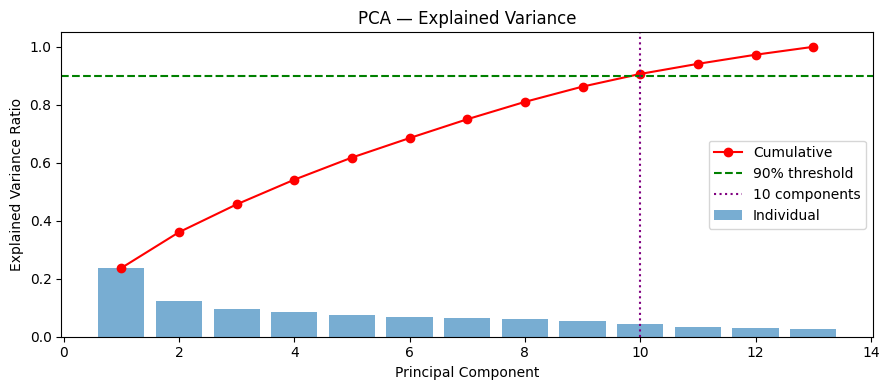

Components needed for 90% explained variance: 10


In [17]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

evr = pca_full.explained_variance_ratio_
cumvar = np.cumsum(evr)
n_90 = np.searchsorted(cumvar, 0.90) + 1

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, len(evr)+1), evr, alpha=0.6, label='Individual')
ax.plot(range(1, len(evr)+1), cumvar, 'o-', color='red', label='Cumulative')
ax.axhline(0.90, color='green', linestyle='--', label='90% threshold')
ax.axvline(n_90, color='purple', linestyle=':', label=f'{n_90} components')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA — Explained Variance')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Components needed for 90% explained variance: {n_90}')

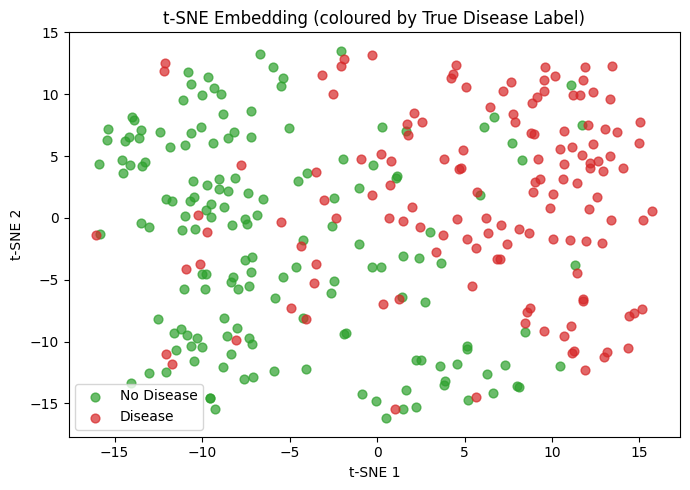

In [18]:
# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=500)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(7, 5))
for lbl, color, name in [(0,'#2ca02c','No Disease'), (1,'#d62728','Disease')]:
    mask = y_true == lbl
    ax.scatter(X_tsne[mask,0], X_tsne[mask,1], label=name,
               alpha=0.7, s=40, color=color)
ax.set_title('t-SNE Embedding (coloured by True Disease Label)')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend()
plt.tight_layout()
plt.show()

**t-SNE Analysis:**

The two classes show partial separation in t-SNE space with some overlapping regions.
Disease-positive patients tend to cluster in distinct zones, while disease-negative
patients are more dispersed. This moderate separability implies the classification
task is non-trivial — a linear classifier will underperform, but non-linear models
(ensemble, neural network) should leverage the structure effectively.